# Diffusion-Guided vs. Gradient (GQR-style) Test-Time Query Refinement
### A proof-of-concept evaluation on small MTEB retrieval subsets

This notebook benchmarks **four test-time methods** for adapting a frozen embedding
model's query representation, on subsampled MTEB/BEIR retrieval tasks:

| Method | Description |
|---|---|
| `original` | Plain cosine ranking with the frozen query embedding |
| `rerank_only` | Teacher reranks only the top-K; rest of ranking unchanged |
| `gqr` | GQR/ReFIT/TOUR-style refinement: Adam gradient descent on the query embedding, minimizing KL(teacher ‖ embedder) over the top-K feedback docs |
| `gqr_trust` | Same, plus an L2 trust-region penalty (the "simple prior" ablation) |
| `diffusion` | **New**: a small diffusion prior trained on the corpus embedding manifold; the query is partially noised, then denoised with the KL feedback loss injected as classifier guidance (SDEdit + DPS-style) |

**Teacher**: a cross-encoder reranker by default (fast, free). A stub is provided to
swap in a true LLM teacher (as in the paper) via any OpenAI/Anthropic-compatible API.

**Outputs**: paper-ready LaTeX tables (MAP / nDCG@10 / Recall@K with % gains and
paired-t significance) and PDF figures (grouped bars, Recall@K curves, PCA
refinement-trajectory plot), saved under `results/`.

> ⚠️ Use a GPU runtime (Runtime → Change runtime type → T4). Full run ≈ 15–30 min
> with the default config (2 datasets × 3 models × 40 queries).
>
> Note: the request mentioned *MIEB*; that is the **image** embedding benchmark.
> Since the methods here operate on text embedders, we use small **MTEB** retrieval
> tasks (NFCorpus, SciFact). Any BEIR-format dataset on the `mteb` HF hub can be
> dropped into `CFG.datasets`.


In [ ]:
# %% 1. Setup
%pip -q install -U sentence-transformers datasets scipy pandas matplotlib

import os, math, random, json, time
from collections import defaultdict
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

os.makedirs("results/tables", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
cudf

In [ ]:
# %% 2. Configuration
@dataclass
class Config:
    # MTEB/BEIR retrieval tasks (any 'mteb/<name>' BEIR-format dataset works)
    datasets: tuple = ("mteb/scifact", "mteb/nfcorpus")
    qrels_split: dict = field(default_factory=lambda: {
        "mteb/scifact": "test", "mteb/nfcorpus": "test"})

    # Small instruction-style embedders that fit a T4 comfortably.
    # value = (query_prefix, doc_prefix)
    models: dict = field(default_factory=lambda: {
        "sentence-transformers/all-MiniLM-L6-v2": ("", ""),
        "intfloat/e5-small-v2": ("query: ", "passage: "),
        "BAAI/bge-small-en-v1.5":
            ("Represent this sentence for searching relevant passages: ", ""),
    })

    teacher_name: str = "cross-encoder/ms-marco-MiniLM-L6-v2"

    # Subsampling for PoC speed
    max_queries: int = 40         # queries per dataset
    max_corpus: int = 3000        # docs per dataset (all positives kept)

    # Feedback / refinement
    k_feedback: int = 20          # docs scored by the teacher (paper: K=20)
    gqr_steps: int = 100          # paper: T=100
    gqr_lr: float = 5e-4
    tau_embed: float = 0.05       # temperature for cosine softmax
    trust_lambda: float = 2.0     # L2 trust-region strength

    # Diffusion prior
    diff_T: int = 200             # diffusion timesteps
    diff_train_iters: int = 1500
    diff_batch: int = 256
    diff_lr: float = 1e-3
    t_start_frac: float = 0.25    # SDEdit: how much noise to inject (0..1)
    guidance_scale: float = 30.0  # DPS guidance strength
    n_diff_samples: int = 4       # samples drawn & score-averaged (ensemble)

    recall_ks: tuple = (10, 20, 50, 100)

CFG = Config()
CFG


Config(datasets=('mteb/scifact', 'mteb/nfcorpus'), qrels_split={'mteb/scifact': 'test', 'mteb/nfcorpus': 'test'}, models={'sentence-transformers/all-MiniLM-L6-v2': ('', ''), 'intfloat/e5-small-v2': ('query: ', 'passage: '), 'BAAI/bge-small-en-v1.5': ('Represent this sentence for searching relevant passages: ', '')}, teacher_name='cross-encoder/ms-marco-MiniLM-L6-v2', max_queries=40, max_corpus=3000, k_feedback=20, gqr_steps=100, gqr_lr=0.0005, tau_embed=0.05, trust_lambda=2.0, diff_T=200, diff_train_iters=1500, diff_batch=256, diff_lr=0.001, t_start_frac=0.25, guidance_scale=30.0, n_diff_samples=4, recall_ks=(10, 20, 50, 100))

In [ ]:
# %% 3. Data loading & subsampling
from datasets import load_dataset

def load_beir_subset(name: str, cfg: Config):
    corpus_ds  = load_dataset(name, "corpus",  split="corpus")
    queries_ds = load_dataset(name, "queries", split="queries")
    qrels_ds   = load_dataset(name, "default", split=cfg.qrels_split[name])

    qrels = defaultdict(dict)
    for r in qrels_ds:
        if float(r["score"]) > 0:
            qrels[str(r["query-id"])][str(r["corpus-id"])] = float(r["score"])

    qtext = {str(r["_id"]): r["text"] for r in queries_ds}
    valid_q = [q for q in qrels if q in qtext and len(qrels[q]) > 0]
    rng = random.Random(SEED)
    rng.shuffle(valid_q)
    q_ids = sorted(valid_q[:cfg.max_queries])

    pos_docs = set()
    for q in q_ids:
        pos_docs |= set(qrels[q].keys())

    all_doc_ids, doc_text = [], {}
    for r in corpus_ds:
        did = str(r["_id"])
        all_doc_ids.append(did)
        doc_text[did] = ((r.get("title") or "") + " " + (r.get("text") or "")).strip()

    negatives = [d for d in all_doc_ids if d not in pos_docs]
    rng.shuffle(negatives)
    keep = list(pos_docs) + negatives[:max(0, cfg.max_corpus - len(pos_docs))]
    keep = sorted(set(keep))

    doc2idx = {d: i for i, d in enumerate(keep)}
    docs = [doc_text[d] for d in keep]
    queries = [(q, qtext[q]) for q in q_ids]
    pos_idx = {q: {doc2idx[d] for d in qrels[q] if d in doc2idx} for q in q_ids}

    print(f"{name}: {len(queries)} queries | corpus {len(docs)} docs "
          f"({len(pos_docs)} positives kept)")
    return {"docs": docs, "queries": queries, "pos_idx": pos_idx}

DATA = {name: load_beir_subset(name, CFG) for name in CFG.datasets}


README.md:   0%|          | 0.00/8.25k [00:00<?, ?B/s]

corpus.jsonl:   0%|          | 0.00/8.02M [00:00<?, ?B/s]

Generating corpus split:   0%|          | 0/5183 [00:00<?, ? examples/s]

queries.jsonl:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating queries split:   0%|          | 0/1109 [00:00<?, ? examples/s]

...

test.jsonl:   0%|          | 0.00/810k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/110575 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/11385 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12334 [00:00<?, ? examples/s]

mteb/nfcorpus: 40 queries | corpus 3000 docs (1046 positives kept)


In [ ]:
# %% 4. Embedders & teacher
from sentence_transformers import SentenceTransformer, CrossEncoder

_teacher = CrossEncoder(CFG.teacher_name, max_length=512, device=DEVICE)

def teacher_scores_crossencoder(query: str, docs: list) -> np.ndarray:
    "Returns raw relevance logits for (query, doc) pairs."
    return np.asarray(_teacher.predict([(query, d) for d in docs],
                                       show_progress_bar=False), dtype=np.float32)

def teacher_scores_llm(query: str, docs: list) -> np.ndarray:
    '''OPTIONAL: faithful replication of the paper's LLM teacher.
    Implement with any logprob-exposing API: ask
      "Is this document relevant for this query? Answer yes/no"
    and return log( P(yes) / P(no) ) per doc. Then set
      TEACHER_FN = teacher_scores_llm
    '''
    raise NotImplementedError

TEACHER_FN = teacher_scores_crossencoder

def embed_all(model_name: str, data: dict):
    qpfx, dpfx = CFG.models[model_name]
    model = SentenceTransformer(model_name, device=DEVICE)
    D = model.encode([dpfx + t for t in data["docs"]], batch_size=128,
                     normalize_embeddings=True, convert_to_numpy=True,
                     show_progress_bar=True)
    Q = model.encode([qpfx + t for _, t in data["queries"]], batch_size=128,
                     normalize_embeddings=True, convert_to_numpy=True)
    del model; torch.cuda.empty_cache()
    return torch.tensor(Q, device=DEVICE), torch.tensor(D, device=DEVICE)


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [ ]:
# %% 5. Metrics
def average_precision(scores: np.ndarray, pos: set) -> float:
    order = np.argsort(-scores)
    hits, s = 0, 0.0
    for rank, idx in enumerate(order, start=1):
        if idx in pos:
            hits += 1
            s += hits / rank
    return s / max(1, len(pos))

def ndcg_at_k(scores: np.ndarray, pos: set, k: int = 10) -> float:
    order = np.argsort(-scores)[:k]
    dcg = sum(1.0 / math.log2(r + 2) for r, i in enumerate(order) if i in pos)
    idcg = sum(1.0 / math.log2(r + 2) for r in range(min(k, len(pos))))
    return dcg / idcg if idcg > 0 else 0.0

def recall_at_k(scores: np.ndarray, pos: set, k: int) -> float:
    order = set(np.argsort(-scores)[:k].tolist())
    return len(order & pos) / max(1, len(pos))

def eval_scores(scores: np.ndarray, pos: set) -> dict:
    out = {"AP": average_precision(scores, pos),
           "nDCG@10": ndcg_at_k(scores, pos, 10)}
    for k in CFG.recall_ks:
        out[f"R@{k}"] = recall_at_k(scores, pos, k)
    return out


In [ ]:
# %% 6. GQR-style gradient refinement (+ trust-region ablation)
def kl_feedback_loss(z, D_top, p_teacher, tau, z0=None, lam=0.0):
    zn = F.normalize(z, dim=-1)
    logits = (zn @ D_top.T) / tau
    loss = F.kl_div(F.log_softmax(logits, dim=-1), p_teacher, reduction="sum")
    if lam > 0.0 and z0 is not None:
        loss = loss + lam * torch.sum((z - z0) ** 2)
    return loss

def gqr_refine(z0, D_top, p_teacher, steps, lr, tau, lam=0.0, record_path=False):
    z = z0.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([z], lr=lr)
    path = [z0.detach().cpu().numpy().copy()] if record_path else None
    for t in range(steps):
        opt.zero_grad()
        loss = kl_feedback_loss(z, D_top, p_teacher, tau, z0=z0, lam=lam)
        loss.backward()
        opt.step()
        if record_path and (t + 1) % 10 == 0:
            path.append(F.normalize(z.detach(), dim=-1).cpu().numpy().copy())
    zf = F.normalize(z.detach(), dim=-1)
    return (zf, path) if record_path else zf


In [ ]:
# %% 7. Diffusion prior over the embedding manifold + guided sampling
class TimeEmb(nn.Module):
    def __init__(self, dim=128):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) *
                          torch.arange(half, device=t.device) / (half - 1))
        a = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(a), torch.cos(a)], dim=-1)

class Denoiser(nn.Module):
    def __init__(self, dim, hidden=512, temb=128):
        super().__init__()
        self.temb = TimeEmb(temb)
        self.net = nn.Sequential(
            nn.Linear(dim + temb, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, dim))
    def forward(self, x, t):
        return self.net(torch.cat([x, self.temb(t)], dim=-1))

class EmbeddingDiffusion:
    "Tiny DDPM over (normalized) embedding vectors; supports DPS-style guidance."
    def __init__(self, dim, T, device):
        self.T, self.device = T, device
        self.betas = torch.linspace(1e-4, 0.02, T, device=device)
        self.alphas = 1.0 - self.betas
        self.ab = torch.cumprod(self.alphas, dim=0)        # alpha_bar
        self.model = Denoiser(dim).to(device)

    def train(self, X, iters, batch, lr):
        opt = torch.optim.Adam(self.model.parameters(), lr=lr)
        n = X.shape[0]
        self.model.train()
        for i in range(iters):
            idx = torch.randint(0, n, (batch,), device=self.device)
            x0 = X[idx]
            t = torch.randint(0, self.T, (batch,), device=self.device)
            noise = torch.randn_like(x0)
            ab = self.ab[t][:, None]
            xt = ab.sqrt() * x0 + (1 - ab).sqrt() * noise
            loss = F.mse_loss(self.model(xt, t), noise)
            opt.zero_grad(); loss.backward(); opt.step()
            if (i + 1) % 500 == 0:
                print(f"  diffusion iter {i+1}/{iters}  loss={loss.item():.4f}")
        self.model.eval()

    @torch.no_grad()
    def _post_mean(self, xt, t, eps):
        a, ab, b = self.alphas[t], self.ab[t], self.betas[t]
        return (xt - b / (1 - ab).sqrt() * eps) / a.sqrt()

    def guided_refine(self, z0, loss_fn, t_start_frac, guidance_scale,
                      record_path=False):
        '''SDEdit-style: partially noise z0, then reverse-diffuse with the
        feedback loss gradient (computed on the x0 estimate) as guidance.'''
        ts = int(t_start_frac * self.T)
        ab0 = self.ab[ts]
        x = ab0.sqrt() * z0 + (1 - ab0).sqrt() * torch.randn_like(z0)
        path = [z0.detach().cpu().numpy().copy()] if record_path else None
        for t in reversed(range(ts)):
            tt = torch.tensor([t], device=self.device)
            x = x.detach().requires_grad_(True)
            eps = self.model(x[None, :], tt)[0]
            ab = self.ab[t]
            x0_hat = (x - (1 - ab).sqrt() * eps) / ab.sqrt()
            g = torch.autograd.grad(loss_fn(x0_hat), x)[0]
            with torch.no_grad():
                mean = self._post_mean(x, t, eps)
                mean = mean - guidance_scale * (1 - ab) * g
                x = mean + (self.betas[t].sqrt() * torch.randn_like(x)
                            if t > 0 else 0.0)
            if record_path and t % max(1, ts // 10) == 0:
                path.append(F.normalize(x.detach(), dim=-1).cpu().numpy().copy())
        zf = F.normalize(x.detach(), dim=-1)
        return (zf, path) if record_path else zf


In [ ]:
# %% 8. Main experiment loop
rows, trajectories = [], {}

for ds_name, data in DATA.items():
    for model_name in CFG.models:
        print(f"\n=== {ds_name} | {model_name} ===")
        Q, D = embed_all(model_name, data)
        dim = D.shape[1]

        # --- train the diffusion prior on the corpus embedding manifold ---
        print("Training diffusion prior on corpus embeddings...")
        prior = EmbeddingDiffusion(dim, CFG.diff_T, DEVICE)
        prior.train(D, CFG.diff_train_iters, CFG.diff_batch, CFG.diff_lr)

        sims_all = (Q @ D.T).cpu().numpy()

        for qi, (qid, qtext) in enumerate(data["queries"]):
            pos = data["pos_idx"][qid]
            base_scores = sims_all[qi]

            topk = np.argsort(-base_scores)[:CFG.k_feedback]
            D_top = D[torch.tensor(topk, device=DEVICE)]
            t_logits = TEACHER_FN(qtext, [data["docs"][i] for i in topk])
            p_teacher = torch.softmax(
                torch.tensor(t_logits, device=DEVICE), dim=-1)

            z0 = Q[qi]
            loss_fn = lambda z: kl_feedback_loss(
                z, D_top, p_teacher, CFG.tau_embed)

            # 1) original
            res = {"original": base_scores}

            # 2) rerank-only: teacher reorders top-K above everything else
            rr = base_scores.copy()
            ceil = rr.max() + 1.0
            order = topk[np.argsort(-t_logits)]
            for r, di in enumerate(order):
                rr[di] = ceil + (len(order) - r)
            res["rerank_only"] = rr

            # 3) GQR
            record = (qi == 0)
            out = gqr_refine(z0, D_top, p_teacher, CFG.gqr_steps, CFG.gqr_lr,
                             CFG.tau_embed, lam=0.0, record_path=record)
            zg, gpath = out if record else (out, None)
            res["gqr"] = (zg @ D.T).cpu().numpy()

            # 4) GQR + trust region
            zt = gqr_refine(z0, D_top, p_teacher, CFG.gqr_steps, CFG.gqr_lr,
                            CFG.tau_embed, lam=CFG.trust_lambda)
            res["gqr_trust"] = (zt @ D.T).cpu().numpy()

            # 5) diffusion-guided (sample ensemble, average corpus scores)
            sc, dpath = None, None
            for s in range(CFG.n_diff_samples):
                rec = record and s == 0
                out = prior.guided_refine(z0, loss_fn, CFG.t_start_frac,
                                          CFG.guidance_scale, record_path=rec)
                zd, p = out if rec else (out, None)
                if p is not None: dpath = p
                cur = (zd @ D.T).cpu().numpy()
                sc = cur if sc is None else sc + cur
            res["diffusion"] = sc / CFG.n_diff_samples

            if record:
                trajectories[(ds_name, model_name)] = dict(
                    gqr=gpath, diffusion=dpath,
                    D=D.cpu().numpy(), pos=pos, topk=topk)

            for method, scores in res.items():
                m = eval_scores(scores, pos)
                rows.append({"dataset": ds_name.split("/")[-1],
                             "model": model_name.split("/")[-1],
                             "method": method, "qid": qid, **m})
        del Q, D, prior; torch.cuda.empty_cache()

df = pd.DataFrame(rows)
df.to_csv("results/raw_per_query.csv", index=False)
df.head()



=== mteb/scifact | sentence-transformers/all-MiniLM-L6-v2 ===


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Training diffusion prior on corpus embeddings...
  diffusion iter 500/1500  loss=0.1894
  diffusion iter 1000/1500  loss=0.1790
  diffusion iter 1500/1500  loss=0.1864

=== mteb/nfcorpus | BAAI/bge-small-en-v1.5 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Training diffusion prior on corpus embeddings...
  diffusion iter 500/1500  loss=0.1860
  diffusion iter 1000/1500  loss=0.1746
  diffusion iter 1500/1500  loss=0.1751


,dataset,model,method,qid,AP,nDCG@10,R@10,R@20,R@50,R@100
0,scifact,all-MiniLM-L6-v2,original,100,0.5,0.63093,1.0,1.0,1.0,1.0
1,scifact,all-MiniLM-L6-v2,rerank_only,100,1.0,1.00000,1.0,1.0,1.0,1.0
2,scifact,all-MiniLM-L6-v2,gqr,100,1.0,1.00000,1.0,1.0,1.0,1.0
3,scifact,all-MiniLM-L6-v2,gqr_trust,100,1.0,1.00000,1.0,1.0,1.0,1.0
4,scifact,all-MiniLM-L6-v2,diffusion,100,1.0,1.00000,1.0,1.0,1.0,1.0


In [ ]:
# %% 9. Paper-ready tables (MAP + significance, LaTeX export)
METHOD_ORDER = ["original", "rerank_only", "gqr", "gqr_trust", "diffusion"]
PRETTY = {"original": "Original", "rerank_only": "Rerank-only",
          "gqr": "GQR (gradient)", "gqr_trust": "GQR + trust-region",
          "diffusion": "Diffusion-guided (ours)"}

def fmt_cell(map_val, base):
    gain = 100.0 * (map_val - base) / max(base, 1e-9)
    return f"{map_val:.3f} ({gain:+.1f}\\%)"

tables = {}
for metric in ["AP", "nDCG@10"]:
    piv = (df.groupby(["dataset", "model", "method"])[metric]
             .mean().unstack("method")[METHOD_ORDER])
    disp = piv.copy().astype(object)
    for idx in piv.index:
        base = piv.loc[idx, "original"]
        for m in METHOD_ORDER:
            disp.loc[idx, m] = (f"{base:.3f}" if m == "original"
                                else fmt_cell(piv.loc[idx, m], base))
    disp.columns = [PRETTY[c] for c in disp.columns]
    name = "MAP" if metric == "AP" else metric
    tables[name] = disp
    tex = disp.to_latex(escape=False, column_format="ll" + "r"*len(METHOD_ORDER),
        caption=f"{name} on subsampled MTEB retrieval tasks. "
                "Percentages are relative gains over the original embeddings.",
        label=f"tab:{name.lower().replace('@','')}")
    with open(f"results/tables/{name.replace('@','')}.tex", "w") as f:
        f.write(tex)
    print(f"\n================ {name} ================")
    display(disp)

# ---- paired one-sided t-tests: diffusion vs gqr, and each vs original ----
sig_rows = []
for (ds, mdl), g in df.groupby(["dataset", "model"]):
    ap = g.pivot(index="qid", columns="method", values="AP")
    for a, b in [("gqr", "original"), ("diffusion", "original"),
                 ("diffusion", "gqr")]:
        t, p = stats.ttest_rel(ap[a], ap[b], alternative="greater")
        sig_rows.append({"dataset": ds, "model": mdl,
                         "comparison": f"{PRETTY[a]} > {PRETTY[b]}",
                         "t": round(float(t), 2),
                         "p-value": f"{p:.2e}",
                         "significant (p<.05)": bool(p < 0.05)})
sig = pd.DataFrame(sig_rows)
sig.to_latex("results/tables/significance.tex", index=False,
             caption="One-sided paired t-tests on per-query AP.",
             label="tab:significance")
print("\n================ Significance (paired t-tests on AP) ================")
display(sig)



================ MAP ================


Original      Rerank-only   GQR (gradient)  \
dataset  model                                                          
nfcorpus all-MiniLM-L6-v2     0.163  0.191 (+16.8\%)  0.207 (+27.0\%)   
         bge-small-en-v1.5    0.183  0.207 (+13.5\%)  0.242 (+32.3\%)   
         e5-small-v2          0.197   0.197 (+0.0\%)  0.220 (+12.1\%)   
scifact  all-MiniLM-L6-v2     0.649   0.707 (+9.0\%)   0.712 (+9.7\%)   
         bge-small-en-v1.5    0.689   0.722 (+4.8\%)   0.724 (+5.1\%)   
         e5-small-v2          0.660   0.701 (+6.2\%)   0.701 (+6.2\%)   

                           GQR + trust-region Diffusion-guided (ours)  
dataset  model                                                         
nfcorpus all-MiniLM-L6-v2     0.198 (+21.2\%)         0.186 (+13.9\%)  
         bge-small-en-v1.5    0.241 (+31.8\%)          0.194 (+6.2\%)  
         e5-small-v2          0.232 (+17.9\%)          0.192 (-2.1\%)  
scifact  all-MiniLM-L6-v2      0.712 (+9.7\%)          0.678 (+4.5\%)  
         bge-small-en-v1.5     0.726 (+5.4\%)          0.708 (+2.8\%)  
         e5-small-v2           0.708 (+7.2\%)          0.679 (+2.9\%)


================ nDCG@10 ================


Original      Rerank-only   GQR (gradient)  \
dataset  model                                                          
nfcorpus all-MiniLM-L6-v2     0.308  0.354 (+14.8\%)  0.390 (+26.6\%)   
         bge-small-en-v1.5    0.355   0.385 (+8.4\%)  0.418 (+17.9\%)   
         e5-small-v2          0.370   0.389 (+5.2\%)   0.403 (+8.8\%)   
scifact  all-MiniLM-L6-v2     0.683   0.732 (+7.2\%)   0.733 (+7.4\%)   
         bge-small-en-v1.5    0.713   0.749 (+5.2\%)   0.735 (+3.1\%)   
         e5-small-v2          0.686   0.727 (+6.0\%)   0.722 (+5.2\%)   

                           GQR + trust-region Diffusion-guided (ours)  
dataset  model                                                         
nfcorpus all-MiniLM-L6-v2     0.368 (+19.5\%)         0.341 (+10.6\%)  
         bge-small-en-v1.5    0.416 (+17.2\%)          0.357 (+0.6\%)  
         e5-small-v2          0.432 (+16.5\%)          0.360 (-2.7\%)  
scifact  all-MiniLM-L6-v2      0.733 (+7.3\%)          0.697 (+2.1\%)  
         bge-small-en-v1.5     0.744 (+4.3\%)          0.726 (+1.8\%)  
         e5-small-v2           0.725 (+5.8\%)          0.698 (+1.8\%)


================ Significance (paired t-tests on AP) ================


,dataset,model,comparison,t,p-value,significant (p<.05)
0,nfcorpus,all-MiniLM-L6-v2,GQR (gradient) > Original,2.78,4.13e-03,True
1,nfcorpus,all-MiniLM-L6-v2,Diffusion-guided (ours) > Original,0.89,1.90e-01,False
2,nfcorpus,all-MiniLM-L6-v2,Diffusion-guided (ours) > GQR (gradient),-0.93,8.21e-01,False
3,nfcorpus,bge-small-en-v1.5,GQR (gradient) > Original,2.55,7.47e-03,True
4,nfcorpus,bge-small-en-v1.5,Diffusion-guided (ours) > Original,0.42,3.39e-01,False
5,nfcorpus,bge-small-en-v1.5,Diffusion-guided (ours) > GQR (gradient),-2.89,9.97e-01,False
6,nfcorpus,e5-small-v2,GQR (gradient) > Original,1.15,1.29e-01,False
7,nfcorpus,e5-small-v2,Diffusion-guided (ours) > Original,-0.17,5.69e-01,False
8,nfcorpus,e5-small-v2,Diffusion-guided (ours) > GQR (gradient),-2.73,9.95e-01,False
9,scifact,all-MiniLM-L6-v2,GQR (gradient) > Original,1.87,3.47e-02,True


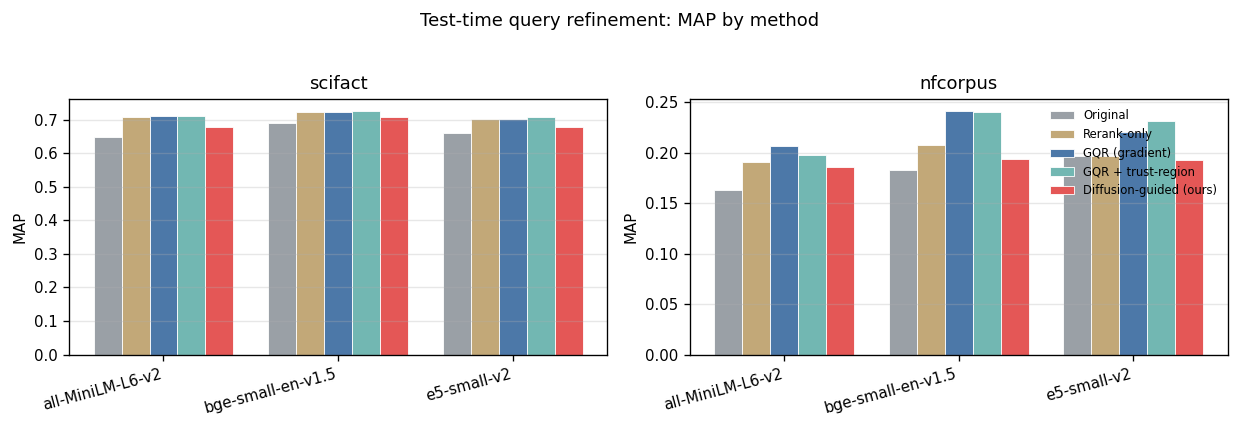

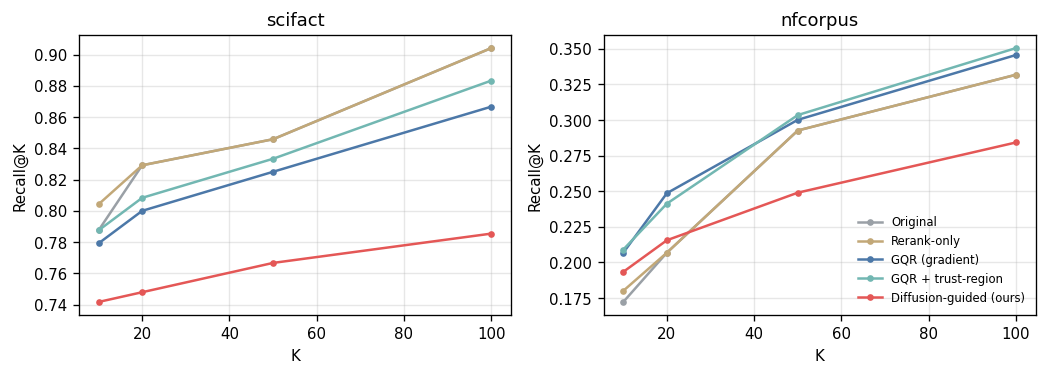

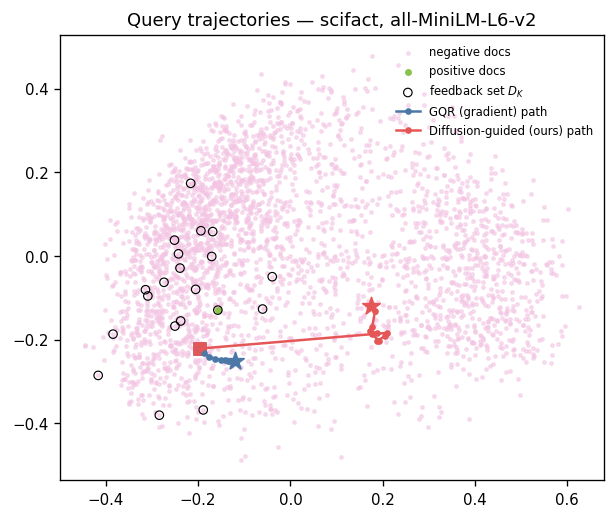

Saved tables -> results/tables/  |  figures -> results/figures/


In [ ]:
# %% 10. Paper-ready figures
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
COLORS = {"original": "#9aa0a6", "rerank_only": "#c2a878",
          "gqr": "#4c78a8", "gqr_trust": "#72b7b2", "diffusion": "#e45756"}

# --- Fig 1: grouped MAP bars per dataset ---
datasets = df["dataset"].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(5.2*len(datasets), 3.4),
                         sharey=False)
axes = np.atleast_1d(axes)
for ax, ds in zip(axes, datasets):
    sub = (df[df.dataset == ds].groupby(["model", "method"])["AP"]
           .mean().unstack("method")[METHOD_ORDER])
    x = np.arange(len(sub.index)); w = 0.16
    for j, m in enumerate(METHOD_ORDER):
        ax.bar(x + (j - 2)*w, sub[m], width=w, label=PRETTY[m],
               color=COLORS[m], edgecolor="white", linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(sub.index, rotation=15, ha="right")
    ax.set_title(ds); ax.set_ylabel("MAP"); ax.grid(axis="y", alpha=0.3)
axes[-1].legend(fontsize=7, frameon=False)
fig.suptitle("Test-time query refinement: MAP by method", y=1.03)
fig.tight_layout()
# fig.savefig("results/figures/map_bars.pdf", bbox_inches="tight")
fig.savefig("results/figures/map_bars.png", bbox_inches="tight"); plt.show()

# --- Fig 2: Recall@K curves (averaged over models), per dataset ---
fig, axes = plt.subplots(1, len(datasets), figsize=(4.4*len(datasets), 3.2))
axes = np.atleast_1d(axes)
ks = list(CFG.recall_ks)
for ax, ds in zip(axes, datasets):
    sub = df[df.dataset == ds]
    for m in METHOD_ORDER:
        vals = [sub[sub.method == m][f"R@{k}"].mean() for k in ks]
        ax.plot(ks, vals, marker="o", ms=3, label=PRETTY[m], color=COLORS[m])
    ax.set_xlabel("K"); ax.set_ylabel("Recall@K"); ax.set_title(ds)
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=7, frameon=False)
fig.tight_layout()
# fig.savefig("results/figures/recall_at_k.pdf", bbox_inches="tight")
fig.savefig("results/figures/recall_at_k.png", bbox_inches="tight"); plt.show()

# --- Fig 3: PCA refinement trajectories (one example query) ---
from sklearn.decomposition import PCA
key = next(iter(trajectories))
traj = trajectories[key]
pca = PCA(n_components=2).fit(traj["D"])
Dp = pca.transform(traj["D"])
labels = np.zeros(len(Dp)); labels[list(traj["pos"])] = 1

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(Dp[labels == 0, 0], Dp[labels == 0, 1], s=4, c="#f3c4e3",
           alpha=0.5, label="negative docs")
ax.scatter(Dp[labels == 1, 0], Dp[labels == 1, 1], s=10, c="#8bc34a",
           label="positive docs")
ax.scatter(Dp[traj["topk"], 0], Dp[traj["topk"], 1], s=26,
           facecolors="none", edgecolors="k", linewidths=0.7,
           label="feedback set $D_K$")
for name, c in [("gqr", COLORS["gqr"]), ("diffusion", COLORS["diffusion"])]:
    P = pca.transform(np.stack(traj[name]))
    ax.plot(P[:, 0], P[:, 1], "-o", ms=3, c=c, label=f"{PRETTY[name]} path")
    ax.scatter(*P[0], marker="s", s=50, c=c)
    ax.scatter(*P[-1], marker="*", s=120, c=c)
ax.set_title(f"Query trajectories — {key[0].split('/')[-1]}, "
             f"{key[1].split('/')[-1]}")
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
# fig.savefig("results/figures/trajectories.pdf", bbox_inches="tight")
fig.savefig("results/figures/trajectories.png", bbox_inches="tight"); plt.show()

print("Saved tables -> results/tables/  |  figures -> results/figures/")


In [ ]:
# # %% 11. (Optional) zip everything for download
# import shutil
# shutil.make_archive("poc_results", "zip", "results")
# print("results/ zipped to poc_results.zip")


## Notes, knobs & caveats

- **Teacher**: the cross-encoder is a fast free stand-in. For a faithful
  replication of the paper's LLM teacher, implement `teacher_scores_llm`
  (yes/no logprob scoring) and set `TEACHER_FN = teacher_scores_llm`.
- **Diffusion prior** is trained on *corpus document* embeddings as a proxy for
  the embedding manifold (plentiful, no extra data needed). A stronger variant
  trains on embeddings of LLM-generated synthetic queries.
- **The key hyperparameters** for the new method are `t_start_frac` (how far the
  query is allowed to move) and `guidance_scale` (how hard the feedback pushes).
  If diffusion underperforms GQR out of the box, sweep
  `t_start_frac ∈ {0.15, 0.25, 0.4}` and `guidance_scale ∈ {10, 30, 100}` on a
  handful of held-out queries first — guided diffusion is sensitive to these.
- **`gqr_trust` is the honest ablation**: if it matches the diffusion method,
  a simple L2 prior suffices and the learned-manifold story doesn't hold.
- Scores here are on a *subsampled* corpus, so absolute numbers are inflated vs.
  full-corpus MTEB; the methods are still compared apples-to-apples.
- To scale up: raise `max_corpus`/`max_queries`, add datasets (e.g.
  `mteb/fiqa`, `mteb/arguana`), or swap in `Qwen/Qwen3-Embedding-0.6B`
  (works on a T4; add `("Instruct: ...\nQuery: ", "")` prefixes).


In [ ]:
# %%writefile analyze_refinement.py
# #!/usr/bin/env python
# # -*- coding: utf-8 -*-
# """
# analyze_refinement.py
# =====================
# Post-hoc probing & interpretability for test-time query refinement
# (GQR-style gradient refinement vs. diffusion-guided refinement).

# Run this AFTER the PoC notebook. Two ways to feed it data:

# (A) PREFERRED - add this cell at the END of the notebook to dump artifacts,
#     then run:  python analyze_refinement.py --artifacts results/artifacts.pt

#     # ---- paste into the notebook as a final cell -------------------------
#     # import torch
#     # torch.save(ARTIFACTS, "results/artifacts.pt")   # see --help for schema
#     # ----------------------------------------------------------------------
#     (If you did not collect ARTIFACTS in the notebook, just use mode B.)

# (B) SELF-CONTAINED - the script recomputes a small probe subset by itself
#     (downloads one dataset + one model, reruns original/GQR/diffusion on a
#     handful of queries) and then analyzes it:

#         python analyze_refinement.py --recompute \
#             --dataset mteb/scifact \
#             --model sentence-transformers/all-MiniLM-L6-v2 \
#             --n-queries 12

# What it produces (under --out, default `analysis/`):

#   1. drift_geometry.csv ........ per-query geometry of the refinement:
#        how far the query moved, whether it moved TOWARD the positive
#        centroid, and how well the drift aligns with the discriminative
#        (pos-centroid minus neg-centroid) axis. Answers "what is actually
#        happening?" quantitatively.
#   2. fig_geometry_scatter.png .. AP-gain vs drift magnitude / axis alignment.
#   3. fig_pca_queries.png ....... PCA panels for example queries: corpus
#        (pos/neg), original query, refined queries, positive centroid,
#        feedback set, drift arrows.
#   4. rank_movement.csv ......... which positives were rescued / negatives
#        suppressed, with before/after ranks.
#   5. token-level probing ....... the drift vector decoded into WORDS:
#        which vocabulary terms the query moved toward / away from.
#   6. highlighted documents ..... displaCy-style HTML where tokens that align
#        with the drift direction are highlighted (uses spaCy's displacy
#        manual mode if spacy is installed; falls back to hand-rolled <mark>
#        HTML otherwise).
#   7. report.html ............... single self-contained report stitching all
#        of the above (tables + figures embedded as base64).

# ARTIFACTS schema (mode A) - a dict keyed by (dataset_name, model_name):
#   {
#     "model_name": str, "dataset": str,
#     "docs": list[str], "queries": list[(qid, qtext)],
#     "pos_idx": {qid: set[int]},
#     "D":  FloatTensor [n_docs, dim]   (normalized doc embeddings, cpu),
#     "Q0": FloatTensor [n_q, dim]      (original query embeddings),
#     "Z":  {"gqr": FloatTensor [n_q, dim], "diffusion": FloatTensor [n_q, dim]},
#     "topk": {qid: np.ndarray[int]},   (feedback doc indices)
#     "teacher": {qid: np.ndarray[float]},  (teacher logits over topk)
#   }
# """

# import argparse
# import base64
# import html
# import io
# import json
# import math
# import os
# import random
# import re
# import sys
# from collections import Counter, defaultdict

# import numpy as np
# import pandas as pd

# # Heavy deps are imported lazily so `--help` is instant.


# # --------------------------------------------------------------------------
# # Small utilities
# # --------------------------------------------------------------------------

# STOPWORDS = set("""a an and are as at be but by for from has have if in into is
# it its of on or that the their then there these this to was were will with we
# you your not no than such can may which our between during each both more most
# other some only own same so too very s t just don should now study studies
# results result using used use show shown two one also however based
# """.split())

# WORD_RE = re.compile(r"[A-Za-z][A-Za-z\-]{2,}")


# def set_seed(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     try:
#         import torch
#         torch.manual_seed(seed)
#     except ImportError:
#         pass


# def fig_to_b64(fig):
#     buf = io.BytesIO()
#     fig.savefig(buf, format="png", bbox_inches="tight", dpi=130)
#     buf.seek(0)
#     return base64.b64encode(buf.read()).decode("ascii")


# def average_precision(scores, pos):
#     order = np.argsort(-scores)
#     hits, s = 0, 0.0
#     for rank, idx in enumerate(order, 1):
#         if idx in pos:
#             hits += 1
#             s += hits / rank
#     return s / max(1, len(pos))


# def feedback_auc(teacher_logits, topk, pos):
#     """AUC of the teacher's feedback scores wrt gold labels (paper Tab.10)."""
#     y = np.array([1 if i in pos else 0 for i in topk])
#     if y.sum() == 0 or y.sum() == len(y):
#         return float("nan")
#     order = np.argsort(teacher_logits)
#     ranks = np.empty_like(order, dtype=float)
#     ranks[order] = np.arange(1, len(y) + 1)
#     n1, n0 = y.sum(), (1 - y).sum()
#     return (ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


# # --------------------------------------------------------------------------
# # Mode B: self-contained recompute of a small probe subset
# # (mirrors the notebook implementation, condensed)
# # --------------------------------------------------------------------------

# def recompute_artifacts(args):
#     import torch
#     import torch.nn as nn
#     import torch.nn.functional as F
#     from datasets import load_dataset
#     from sentence_transformers import SentenceTransformer, CrossEncoder

#     device = "cuda" if torch.cuda.is_available() else "cpu"
#     print(f"[recompute] device={device}")
#     set_seed(args.seed)

#     # ---- data -------------------------------------------------------------
#     name = args.dataset
#     corpus_ds = load_dataset(name, "corpus", split="corpus")
#     queries_ds = load_dataset(name, "queries", split="queries")
#     qrels_ds = load_dataset(name, "default", split=args.qrels_split)

#     qrels = defaultdict(dict)
#     for r in qrels_ds:
#         if float(r["score"]) > 0:
#             qrels[str(r["query-id"])][str(r["corpus-id"])] = float(r["score"])
#     qtext = {str(r["_id"]): r["text"] for r in queries_ds}
#     valid_q = [q for q in qrels if q in qtext]
#     rng = random.Random(args.seed)
#     rng.shuffle(valid_q)
#     q_ids = sorted(valid_q[: args.n_queries])

#     pos_docs = set()
#     for q in q_ids:
#         pos_docs |= set(qrels[q])
#     doc_text, all_ids = {}, []
#     for r in corpus_ds:
#         did = str(r["_id"])
#         all_ids.append(did)
#         doc_text[did] = ((r.get("title") or "") + " " + (r.get("text") or "")).strip()
#     negs = [d for d in all_ids if d not in pos_docs]
#     rng.shuffle(negs)
#     keep = sorted(set(list(pos_docs) + negs[: max(0, args.max_corpus - len(pos_docs))]))
#     d2i = {d: i for i, d in enumerate(keep)}
#     docs = [doc_text[d] for d in keep]
#     queries = [(q, qtext[q]) for q in q_ids]
#     pos_idx = {q: {d2i[d] for d in qrels[q] if d in d2i} for q in q_ids}
#     print(f"[recompute] {name}: {len(queries)} queries, {len(docs)} docs")

#     # ---- embeddings ---------------------------------------------------------
#     qpfx, dpfx = {
#         "intfloat/e5-small-v2": ("query: ", "passage: "),
#         "BAAI/bge-small-en-v1.5":
#             ("Represent this sentence for searching relevant passages: ", ""),
#     }.get(args.model, ("", ""))

#     st = SentenceTransformer(args.model, device=device)
#     D = torch.tensor(st.encode([dpfx + t for t in docs], batch_size=128,
#                                normalize_embeddings=True,
#                                show_progress_bar=True), device=device)
#     Q0 = torch.tensor(st.encode([qpfx + t for _, t in queries],
#                                 normalize_embeddings=True), device=device)
#     dim = D.shape[1]

#     teacher = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2",
#                            max_length=512, device=device)

#     # ---- refinement methods -------------------------------------------------
#     TAU, STEPS, LR = 0.05, 100, 5e-4

#     def kl_loss(z, Dt, p_t):
#         zn = F.normalize(z, dim=-1)
#         return F.kl_div(F.log_softmax((zn @ Dt.T) / TAU, dim=-1),
#                         p_t, reduction="sum")

#     def gqr(z0, Dt, p_t):
#         z = z0.clone().detach().requires_grad_(True)
#         opt = torch.optim.Adam([z], lr=LR)
#         for _ in range(STEPS):
#             opt.zero_grad()
#             kl_loss(z, Dt, p_t).backward()
#             opt.step()
#         return F.normalize(z.detach(), dim=-1)

#     class TimeEmb(nn.Module):
#         def __init__(self, dim=128):
#             super().__init__()
#             self.dim = dim

#         def forward(self, t):
#             half = self.dim // 2
#             freqs = torch.exp(-math.log(10000) *
#                               torch.arange(half, device=t.device) / (half - 1))
#             a = t.float()[:, None] * freqs[None, :]
#             return torch.cat([torch.sin(a), torch.cos(a)], -1)

#     class Denoiser(nn.Module):
#         def __init__(self, dim, hidden=512):
#             super().__init__()
#             self.te = TimeEmb()
#             self.net = nn.Sequential(nn.Linear(dim + 128, hidden), nn.SiLU(),
#                                      nn.Linear(hidden, hidden), nn.SiLU(),
#                                      nn.Linear(hidden, dim))

#         def forward(self, x, t):
#             return self.net(torch.cat([x, self.te(t)], -1))

#     T = 200
#     betas = torch.linspace(1e-4, 0.02, T, device=device)
#     alphas = 1 - betas
#     ab = torch.cumprod(alphas, 0)
#     dn = Denoiser(dim).to(device)
#     opt = torch.optim.Adam(dn.parameters(), lr=1e-3)
#     print("[recompute] training diffusion prior ...")
#     for i in range(args.diff_iters):
#         idx = torch.randint(0, D.shape[0], (256,), device=device)
#         x0 = D[idx]
#         t = torch.randint(0, T, (256,), device=device)
#         noise = torch.randn_like(x0)
#         xt = ab[t][:, None].sqrt() * x0 + (1 - ab[t][:, None]).sqrt() * noise
#         loss = F.mse_loss(dn(xt, t), noise)
#         opt.zero_grad()
#         loss.backward()
#         opt.step()
#     dn.eval()

#     def diffusion_refine(z0, loss_fn, t_frac=0.25, gscale=30.0):
#         ts = int(t_frac * T)
#         x = ab[ts].sqrt() * z0 + (1 - ab[ts]).sqrt() * torch.randn_like(z0)
#         for t in reversed(range(ts)):
#             tt = torch.tensor([t], device=device)
#             x = x.detach().requires_grad_(True)
#             eps = dn(x[None], tt)[0]
#             x0_hat = (x - (1 - ab[t]).sqrt() * eps) / ab[t].sqrt()
#             g = torch.autograd.grad(loss_fn(x0_hat), x)[0]
#             with torch.no_grad():
#                 mean = (x - betas[t] / (1 - ab[t]).sqrt() * eps) / alphas[t].sqrt()
#                 x = mean - gscale * (1 - ab[t]) * g
#                 if t > 0:
#                     x = x + betas[t].sqrt() * torch.randn_like(x)
#         return F.normalize(x.detach(), dim=-1)

#     # ---- run per query ------------------------------------------------------
#     K = 20
#     Zg = torch.zeros_like(Q0)
#     Zd = torch.zeros_like(Q0)
#     topk_d, teach_d = {}, {}
#     sims = (Q0 @ D.T).cpu().numpy()
#     for qi, (qid, qtx) in enumerate(queries):
#         topk = np.argsort(-sims[qi])[:K]
#         Dt = D[torch.tensor(topk, device=device)]
#         logits = np.asarray(teacher.predict([(qtx, docs[i]) for i in topk],
#                                             show_progress_bar=False),
#                             dtype=np.float32)
#         p_t = torch.softmax(torch.tensor(logits, device=device), -1)
#         Zg[qi] = gqr(Q0[qi], Dt, p_t)
#         acc = None
#         for _ in range(4):
#             zd = diffusion_refine(Q0[qi], lambda z: kl_loss(z, Dt, p_t))
#             acc = zd if acc is None else acc + zd
#         Zd[qi] = F.normalize(acc / 4, dim=-1)
#         topk_d[qid], teach_d[qid] = topk, logits
#         print(f"[recompute] query {qi+1}/{len(queries)} done")

#     art = {(name, args.model): {
#         "model_name": args.model, "dataset": name,
#         "docs": docs, "queries": queries, "pos_idx": pos_idx,
#         "D": D.cpu(), "Q0": Q0.cpu(),
#         "Z": {"gqr": Zg.cpu(), "diffusion": Zd.cpu()},
#         "topk": topk_d, "teacher": teach_d,
#     }}
#     os.makedirs(os.path.dirname(args.artifacts) or ".", exist_ok=True)
#     torch.save(art, args.artifacts)
#     print(f"[recompute] artifacts saved to {args.artifacts}")
#     return art


# # --------------------------------------------------------------------------
# # Analysis 1: drift geometry - "what actually happened to the query?"
# # --------------------------------------------------------------------------

# def analyze_geometry(art, out_dir):
#     import torch
#     import torch.nn.functional as F
#     import matplotlib.pyplot as plt

#     rows = []
#     for (ds, mdl), A in art.items():
#         D, Q0 = A["D"], A["Q0"]
#         sims0 = (Q0 @ D.T).numpy()
#         for method, Z in A["Z"].items():
#             simsZ = (Z @ D.T).numpy()
#             for qi, (qid, _) in enumerate(A["queries"]):
#                 pos = A["pos_idx"][qid]
#                 neg_mask = np.ones(D.shape[0], bool)
#                 neg_mask[list(pos)] = False
#                 c_pos = F.normalize(D[list(pos)].mean(0), dim=-1)
#                 c_neg = F.normalize(D[torch.tensor(np.where(neg_mask)[0])]
#                                     .mean(0), dim=-1)
#                 axis = F.normalize(c_pos - c_neg, dim=-1)   # discriminative axis

#                 z0, z = Q0[qi], Z[qi]
#                 drift = z - z0
#                 dn = drift.norm().item()
#                 drift_dir = drift / max(dn, 1e-9)
#                 to_centroid = F.normalize(c_pos - z0, dim=-1)

#                 rows.append({
#                     "dataset": ds.split("/")[-1], "model": mdl.split("/")[-1],
#                     "method": method, "qid": qid,
#                     "drift_norm": dn,
#                     "cos(z0,z)": float((z0 @ z)),
#                     "cos(z0,c_pos)": float((z0 @ c_pos)),
#                     "cos(z,c_pos)": float((z @ c_pos)),
#                     "moved_toward_centroid":
#                         float((z @ c_pos) - (z0 @ c_pos)) > 0,
#                     "cos(drift,to_centroid)": float((drift_dir @ to_centroid)),
#                     "cos(drift,disc_axis)": float((drift_dir @ axis)),
#                     "AP_before": average_precision(sims0[qi], pos),
#                     "AP_after": average_precision(simsZ[qi], pos),
#                     "feedback_AUC": feedback_auc(A["teacher"][qid],
#                                                  A["topk"][qid], pos),
#                 })
#     geo = pd.DataFrame(rows)
#     geo["AP_gain"] = geo["AP_after"] - geo["AP_before"]
#     geo.to_csv(os.path.join(out_dir, "drift_geometry.csv"), index=False)

#     # headline summary, replicating the paper's qualitative claims
#     summary = (geo.groupby("method")
#                .agg(mean_drift=("drift_norm", "mean"),
#                     pct_toward_centroid=("moved_toward_centroid", "mean"),
#                     mean_axis_alignment=("cos(drift,disc_axis)", "mean"),
#                     mean_AP_gain=("AP_gain", "mean"))
#                .round(3))

#     # correlations: what predicts a gain?
#     corr_rows = []
#     for m, g in geo.groupby("method"):
#         for feat in ["drift_norm", "cos(drift,disc_axis)",
#                      "cos(drift,to_centroid)", "feedback_AUC"]:
#             sub = g[[feat, "AP_gain"]].dropna()
#             if len(sub) > 3:
#                 r = np.corrcoef(sub[feat], sub["AP_gain"])[0, 1]
#                 corr_rows.append({"method": m, "feature": feat,
#                                   "pearson_r_with_AP_gain": round(float(r), 3)})
#     corr = pd.DataFrame(corr_rows)

#     # scatter figure
#     fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
#     for m, g in geo.groupby("method"):
#         axes[0].scatter(g["drift_norm"], g["AP_gain"], s=18, alpha=0.7, label=m)
#         axes[1].scatter(g["cos(drift,disc_axis)"], g["AP_gain"], s=18,
#                         alpha=0.7, label=m)
#     axes[0].set_xlabel("drift magnitude ||z - z0||")
#     axes[1].set_xlabel("cos(drift, discriminative axis)")
#     for ax in axes:
#         ax.set_ylabel("AP gain")
#         ax.axhline(0, c="gray", lw=0.6)
#         ax.grid(alpha=0.3)
#     axes[1].legend(fontsize=8, frameon=False)
#     fig.suptitle("What predicts a successful refinement?")
#     fig.tight_layout()
#     fig.savefig(os.path.join(out_dir, "fig_geometry_scatter.png"),
#                 bbox_inches="tight", dpi=130)
#     return geo, summary, corr, fig


# # --------------------------------------------------------------------------
# # Analysis 2: PCA panels per example query (drift vs centroid, visually)
# # --------------------------------------------------------------------------

# def analyze_pca(art, out_dir, n_examples=4):
#     import torch
#     import torch.nn.functional as F
#     import matplotlib.pyplot as plt
#     from sklearn.decomposition import PCA

#     (ds, mdl), A = next(iter(art.items()))
#     D, Q0 = A["D"].numpy(), A["Q0"]
#     pca = PCA(n_components=2).fit(D)
#     Dp = pca.transform(D)

#     n = min(n_examples, len(A["queries"]))
#     fig, axes = plt.subplots(1, n, figsize=(4.3 * n, 3.9))
#     axes = np.atleast_1d(axes)
#     for ax, qi in zip(axes, range(n)):
#         qid, qtx = A["queries"][qi]
#         pos = list(A["pos_idx"][qid])
#         c_pos = F.normalize(A["D"][pos].mean(0), dim=-1).numpy()
#         lab = np.zeros(len(Dp))
#         lab[pos] = 1
#         ax.scatter(Dp[lab == 0, 0], Dp[lab == 0, 1], s=3, c="#f0c6e2",
#                    alpha=0.45)
#         ax.scatter(Dp[lab == 1, 0], Dp[lab == 1, 1], s=14, c="#7cb342",
#                    label="positives")
#         tk = A["topk"][qid]
#         ax.scatter(Dp[tk, 0], Dp[tk, 1], s=30, facecolors="none",
#                    edgecolors="k", lw=0.7, label="$D_K$ feedback")
#         cp = pca.transform(c_pos[None])[0]
#         ax.scatter(*cp, marker="X", s=110, c="#fbc02d", edgecolors="k",
#                    label="pos. centroid", zorder=5)
#         p0 = pca.transform(Q0[qi].numpy()[None])[0]
#         ax.scatter(*p0, marker="o", s=70, c="k", label="original q", zorder=5)
#         for m, c in [("gqr", "#4c78a8"), ("diffusion", "#e45756")]:
#             pz = pca.transform(A["Z"][m][qi].numpy()[None])[0]
#             ax.annotate("", xy=pz, xytext=p0,
#                         arrowprops=dict(arrowstyle="->", color=c, lw=1.6))
#             ax.scatter(*pz, marker="*", s=150, c=c, label=f"{m} refined",
#                        zorder=6)
#         ax.set_title(f"q={qid}: {qtx[:38]}...", fontsize=8)
#         if qi == 0:
#             ax.legend(fontsize=6, frameon=False)
#     fig.suptitle(f"Query drift vs. positive centroid - {ds}, {mdl}", y=1.03)
#     fig.tight_layout()
#     fig.savefig(os.path.join(out_dir, "fig_pca_queries.png"),
#                 bbox_inches="tight", dpi=130)
#     return fig


# # --------------------------------------------------------------------------
# # Analysis 3: rank movement - rescued positives / suppressed negatives
# # --------------------------------------------------------------------------

# def analyze_rank_movement(art, out_dir, top_show=8):
#     rows, qual_examples = [], []
#     for (ds, mdl), A in art.items():
#         sims0 = (A["Q0"] @ A["D"].T).numpy()
#         for method, Z in A["Z"].items():
#             simsZ = (Z @ A["D"].T).numpy()
#             for qi, (qid, qtx) in enumerate(A["queries"]):
#                 pos = A["pos_idx"][qid]
#                 r0 = np.empty(sims0.shape[1], int)
#                 r0[np.argsort(-sims0[qi])] = np.arange(1, sims0.shape[1] + 1)
#                 rZ = np.empty_like(r0)
#                 rZ[np.argsort(-simsZ[qi])] = np.arange(1, sims0.shape[1] + 1)
#                 for d in pos:
#                     rows.append({"dataset": ds.split("/")[-1],
#                                  "model": mdl.split("/")[-1],
#                                  "method": method, "qid": qid, "doc_idx": d,
#                                  "rank_before": int(r0[d]),
#                                  "rank_after": int(rZ[d]),
#                                  "delta": int(r0[d] - rZ[d]),
#                                  "rescued_into_top20":
#                                      bool(r0[d] > 20 and rZ[d] <= 20)})
#                 # qualitative example: biggest single rescue for this query
#                 deltas = {d: r0[d] - rZ[d] for d in pos}
#                 if deltas:
#                     best = max(deltas, key=deltas.get)
#                     if deltas[best] > 0:
#                         qual_examples.append({
#                             "method": method, "qid": qid, "query": qtx,
#                             "doc_idx": best,
#                             "rank_before": int(r0[best]),
#                             "rank_after": int(rZ[best]),
#                             "doc_snippet": A["docs"][best][:400],
#                         })
#     mv = pd.DataFrame(rows)
#     mv.to_csv(os.path.join(out_dir, "rank_movement.csv"), index=False)
#     rescued = (mv.groupby("method")
#                .agg(positives=("doc_idx", "count"),
#                     mean_rank_delta=("delta", "mean"),
#                     rescued_into_top20=("rescued_into_top20", "sum"))
#                .round(2))
#     qual = (pd.DataFrame(qual_examples)
#             .sort_values("rank_before", ascending=False)
#             .head(top_show))
#     return mv, rescued, qual


# # --------------------------------------------------------------------------
# # Analysis 4: token-level probing - decode the drift vector into words
# # --------------------------------------------------------------------------

# def build_vocab(docs, max_words=1500):
#     cnt = Counter()
#     for d in docs:
#         for w in WORD_RE.findall(d.lower()):
#             if w not in STOPWORDS:
#                 cnt[w] += 1
#     return [w for w, c in cnt.most_common(max_words) if c >= 3]


# def analyze_tokens(art, out_dir, n_queries=4, topn=12):
#     """For each example query: rank corpus vocabulary by how much the refined
#     query gained/lost affinity to each word -> 'the query drifted toward X'."""
#     import torch
#     import torch.nn.functional as F
#     from sentence_transformers import SentenceTransformer

#     (ds, mdl), A = next(iter(art.items()))
#     device = "cuda" if torch.cuda.is_available() else "cpu"
#     st = SentenceTransformer(A["model_name"], device=device)

#     vocab = build_vocab(A["docs"])
#     W = torch.tensor(st.encode(vocab, batch_size=256,
#                                normalize_embeddings=True,
#                                show_progress_bar=True))
#     sections = []
#     for qi in range(min(n_queries, len(A["queries"]))):
#         qid, qtx = A["queries"][qi]
#         entry = {"qid": qid, "query": qtx, "methods": {}}
#         s0 = W @ A["Q0"][qi]
#         for m, Z in A["Z"].items():
#             gain = (W @ Z[qi]) - s0
#             order = torch.argsort(gain, descending=True)
#             entry["methods"][m] = {
#                 "toward": [(vocab[i], round(float(gain[i]), 3))
#                            for i in order[:topn].tolist()],
#                 "away": [(vocab[i], round(float(gain[i]), 3))
#                          for i in order[-topn:].tolist()][::-1],
#             }
#         sections.append(entry)

#     with open(os.path.join(out_dir, "token_probing.json"), "w") as f:
#         json.dump(sections, f, indent=2)
#     return sections, st, W, vocab


# # --------------------------------------------------------------------------
# # Analysis 5: highlighted documents (displaCy-style)
# # --------------------------------------------------------------------------

# def highlight_doc_html(doc_text, word_scores, threshold=0.35):
#     """Hand-rolled highlighting: tokens whose alignment with the drift
#     direction exceeds `threshold` get a heat-colored background."""
#     out = []
#     for tok in re.split(r"(\W+)", doc_text[:1200]):
#         key = tok.lower()
#         s = word_scores.get(key, 0.0)
#         if s > threshold:
#             alpha = min(0.85, 0.25 + s)
#             out.append(f'<mark style="background:rgba(228,87,86,{alpha:.2f});'
#                        f'border-radius:3px;" title="drift align={s:.2f}">'
#                        f"{html.escape(tok)}</mark>")
#         else:
#             out.append(html.escape(tok))
#     return "".join(out)


# def try_displacy(doc_text, word_scores, threshold=0.35):
#     """If spaCy is available, render the same highlights through displacy's
#     manual entity renderer (nicer typography). Returns HTML or None."""
#     try:
#         from spacy import displacy
#     except ImportError:
#         return None
#     text = doc_text[:1200]
#     ents = []
#     for match in WORD_RE.finditer(text):
#         s = word_scores.get(match.group(0).lower(), 0.0)
#         if s > threshold:
#             ents.append({"start": match.start(), "end": match.end(),
#                          "label": f"DRIFT {s:.2f}"})
#     doc = {"text": text, "ents": ents, "title": None}
#     return displacy.render(doc, style="ent", manual=True, page=False,
#                            options={"colors": {}})


# def analyze_highlights(art, st, sections, out_dir, per_query_docs=2):
#     """For each example query and the diffusion-refined query, highlight the
#     top newly-promoted documents by token alignment with the drift vector."""
#     import torch
#     import torch.nn.functional as F

#     (ds, mdl), A = next(iter(art.items()))
#     blocks = []
#     for entry in sections:
#         qid = entry["qid"]
#         qi = [i for i, (q, _) in enumerate(A["queries"]) if q == qid][0]
#         pos = A["pos_idx"][qid]
#         for m, Z in A["Z"].items():
#             drift = F.normalize(Z[qi] - A["Q0"][qi], dim=-1)
#             simsZ = (Z[qi] @ A["D"].T).numpy()
#             sims0 = (A["Q0"][qi] @ A["D"].T).numpy()
#             r0 = np.empty(len(sims0), int)
#             r0[np.argsort(-sims0)] = np.arange(1, len(sims0) + 1)
#             promoted = np.argsort(-simsZ)[:10]
#             promoted = [d for d in promoted if r0[d] > 10][:per_query_docs]
#             for d in promoted:
#                 words = sorted(set(WORD_RE.findall(A["docs"][d].lower()))
#                                - STOPWORDS)
#                 if not words:
#                     continue
#                 We = torch.tensor(st.encode(words, batch_size=256,
#                                             normalize_embeddings=True))
#                 sc = {w: float(s) for w, s in zip(words, (We @ drift))}
#                 body = (try_displacy(A["docs"][d], sc)
#                         or highlight_doc_html(A["docs"][d], sc))
#                 blocks.append({
#                     "qid": qid, "query": entry["query"], "method": m,
#                     "doc_idx": int(d), "rank_before": int(r0[d]),
#                     "is_positive": d in pos, "html": body,
#                 })
#     return blocks


# # --------------------------------------------------------------------------
# # Report
# # --------------------------------------------------------------------------

# REPORT_CSS = """
# body{font-family:Georgia,serif;max-width:980px;margin:40px auto;color:#222;
#      line-height:1.5;padding:0 16px}
# h1{font-size:1.6em} h2{border-bottom:1px solid #ddd;padding-bottom:4px}
# table{border-collapse:collapse;font-size:0.85em;margin:10px 0}
# td,th{border:1px solid #ccc;padding:4px 8px;text-align:right}
# th{background:#f5f5f5} td:first-child,th:first-child{text-align:left}
# .doc{border:1px solid #e0e0e0;border-radius:6px;padding:10px 14px;margin:10px 0;
#      font-size:0.9em;background:#fafafa}
# .tag{display:inline-block;font-size:0.75em;padding:1px 7px;border-radius:9px;
#      margin-right:6px;color:#fff}
# .pos{background:#7cb342}.neg{background:#bbb}
# .words{font-size:0.9em}.toward{color:#c62828}.away{color:#1565c0}
# img{max-width:100%}
# """


# def write_report(out_dir, summary, corr, geo, rescued, qual, sections,
#                  blocks, fig_geo, fig_pca):
#     P = []
#     P.append(f"<html><head><meta charset='utf-8'>"
#              f"<style>{REPORT_CSS}</style></head><body>")
#     P.append("<h1>Probing test-time query refinement</h1>"
#              "<p>Post-hoc interpretability of GQR-style gradient refinement "
#              "vs. diffusion-guided refinement.</p>")

#     P.append("<h2>1 · What actually happened to the query? (geometry)</h2>")
#     P.append("<p>Per-method averages: how far queries moved, the fraction "
#              "that moved <i>toward</i> the positive centroid, and how well "
#              "the drift aligns with the discriminative pos&minus;neg axis. "
#              "The paper claims refinement finds a 'better vantage point' "
#              "rather than the centroid &mdash; this table tests that "
#              "directly on your run.</p>")
#     P.append(summary.to_html())
#     P.append("<p>Correlates of a successful refinement "
#              "(Pearson r vs. per-query AP gain). <code>feedback_AUC</code> "
#              "replicates the paper's Table-10 probe with your teacher.</p>")
#     P.append(corr.to_html(index=False))
#     P.append(f"<img src='data:image/png;base64,{fig_to_b64(fig_geo)}'>")

#     P.append("<h2>2 · PCA: drift vs. centroid, visually</h2>")
#     P.append(f"<img src='data:image/png;base64,{fig_to_b64(fig_pca)}'>")

#     P.append("<h2>3 · Rank movement</h2>")
#     P.append("<p>Positives rescued into the top-20 prove the refinement "
#              "generalizes <i>beyond</i> the feedback set (the paper's "
#              "Fig.&nbsp;2b argument).</p>")
#     P.append(rescued.to_html())
#     P.append("<h3>Biggest individual rescues</h3>")
#     for _, r in qual.iterrows():
#         P.append(f"<div class='doc'><b>{html.escape(str(r['method']))}</b> · "
#                  f"q={html.escape(str(r['qid']))} · rank "
#                  f"{r['rank_before']} &rarr; {r['rank_after']}<br>"
#                  f"<i>Query:</i> {html.escape(r['query'][:160])}<br>"
#                  f"<i>Doc:</i> {html.escape(r['doc_snippet'])}…</div>")

#     P.append("<h2>4 · Decoding the drift vector into words</h2>")
#     P.append("<p>Vocabulary terms whose affinity with the query increased "
#              "most (<span class='toward'>toward</span>) or decreased most "
#              "(<span class='away'>away</span>) after refinement &mdash; a "
#              "linear probe of <i>what the feedback taught the query</i>.</p>")
#     for e in sections:
#         P.append(f"<div class='doc'><b>q={html.escape(e['qid'])}</b>: "
#                  f"{html.escape(e['query'][:160])}")
#         for m, d in e["methods"].items():
#             tw = ", ".join(w for w, _ in d["toward"])
#             aw = ", ".join(w for w, _ in d["away"])
#             P.append(f"<div class='words'><b>{m}</b> &mdash; "
#                      f"<span class='toward'>toward:</span> {html.escape(tw)}"
#                      f"<br><span class='away'>away:</span> "
#                      f"{html.escape(aw)}</div>")
#         P.append("</div>")

#     P.append("<h2>5 · Highlighted documents (displaCy-style)</h2>")
#     P.append("<p>Newly promoted documents with tokens highlighted by their "
#              "alignment to the drift direction &mdash; i.e., <i>which words "
#              "in the document the refined query is now attending to</i>.</p>")
#     for b in blocks:
#         tag = ("<span class='tag pos'>POSITIVE</span>" if b["is_positive"]
#                else "<span class='tag neg'>negative</span>")
#         P.append(f"<div class='doc'>{tag}<b>{html.escape(b['method'])}</b> · "
#                  f"q={html.escape(b['qid'])} · was rank {b['rank_before']}, "
#                  f"now top-10<br>{b['html']}</div>")

#     P.append("</body></html>")
#     path = os.path.join(out_dir, "report.html")
#     with open(path, "w", encoding="utf-8") as f:
#         f.write("\n".join(P))
#     return path


# # --------------------------------------------------------------------------
# # Main
# # --------------------------------------------------------------------------

# def main():
#     ap = argparse.ArgumentParser(
#         description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
#     ap.add_argument("--artifacts", default="results/artifacts.pt")
#     ap.add_argument("--out", default="analysis")
#     ap.add_argument("--recompute", action="store_true",
#                     help="ignore/regenerate artifacts by rerunning a small probe")
#     ap.add_argument("--dataset", default="mteb/scifact")
#     ap.add_argument("--qrels-split", default="test")
#     ap.add_argument("--model",
#                     default="sentence-transformers/all-MiniLM-L6-v2")
#     ap.add_argument("--n-queries", type=int, default=12)
#     ap.add_argument("--max-corpus", type=int, default=1500)
#     ap.add_argument("--diff-iters", type=int, default=800)
#     ap.add_argument("--seed", type=int, default=42)
#     args = ap.parse_args()

#     import torch
#     set_seed(args.seed)
#     os.makedirs(args.out, exist_ok=True)

#     if args.recompute or not os.path.exists(args.artifacts):
#         if not args.recompute:
#             print(f"[info] {args.artifacts} not found -> recomputing probe "
#                   f"subset (use the notebook save-cell to skip this).")
#         art = recompute_artifacts(args)
#     else:
#         art = torch.load(args.artifacts, weights_only=False)
#         print(f"[info] loaded artifacts for {len(art)} (dataset, model) pairs")

#     print("[1/5] drift geometry ...")
#     geo, summary, corr, fig_geo = analyze_geometry(art, args.out)
#     print(summary, "\n")

#     print("[2/5] PCA panels ...")
#     fig_pca = analyze_pca(art, args.out)

#     print("[3/5] rank movement ...")
#     _, rescued, qual = analyze_rank_movement(art, args.out)
#     print(rescued, "\n")

#     print("[4/5] token-level probing ...")
#     sections, st, _, _ = analyze_tokens(art, args.out)

#     print("[5/5] highlighted documents ...")
#     blocks = analyze_highlights(art, st, sections, args.out)

#     path = write_report(args.out, summary, corr, geo, rescued, qual,
#                         sections, blocks, fig_geo, fig_pca)
#     print(f"\nDone. Open {path} in a browser.")
#     print(f"CSV/JSON assets in {args.out}/")


# if __name__ == "__main__":
#     main()

usage: colab_kernel_launcher.py [-h] [--artifacts ARTIFACTS] [--out OUT]
                                [--recompute] [--dataset DATASET]
                                [--qrels-split QRELS_SPLIT] [--model MODEL]
                                [--n-queries N_QUERIES]
                                [--max-corpus MAX_CORPUS]
                                [--diff-iters DIFF_ITERS] [--seed SEED]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-98a1161e-f763-45f7-a690-d8fa28964020.json


SystemExit: 2

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


[recompute] device=cuda
[recompute] mteb/scifact: 12 queries, 1500 docs
Loading weights: 100% 103/103 [00:00<00:00, 6103.52it/s]
Batches: 100% 12/12 [00:04<00:00,  2.48it/s]
Loading weights: 100% 105/105 [00:00<00:00, 5059.18it/s]
[recompute] training diffusion prior ...
[recompute] query 1/12 done
[recompute] query 2/12 done
[recompute] query 3/12 done
[recompute] query 4/12 done
[recompute] query 5/12 done
[recompute] query 6/12 done
[recompute] query 7/12 done
[recompute] query 8/12 done
[recompute] query 9/12 done
[recompute] query 10/12 done
[recompute] query 11/12 done
[recompute] query 12/12 done
[recompute] artifacts saved to results/artifacts.pt
[1/5] drift geometry ...
           mean_drift  pct_toward_centroid  mean_axis_alignment  mean_AP_gain
method                                                                       
diffusion       1.169                0.417                0.122         0.023
gqr             0.367                0.833                0.333         0.032 


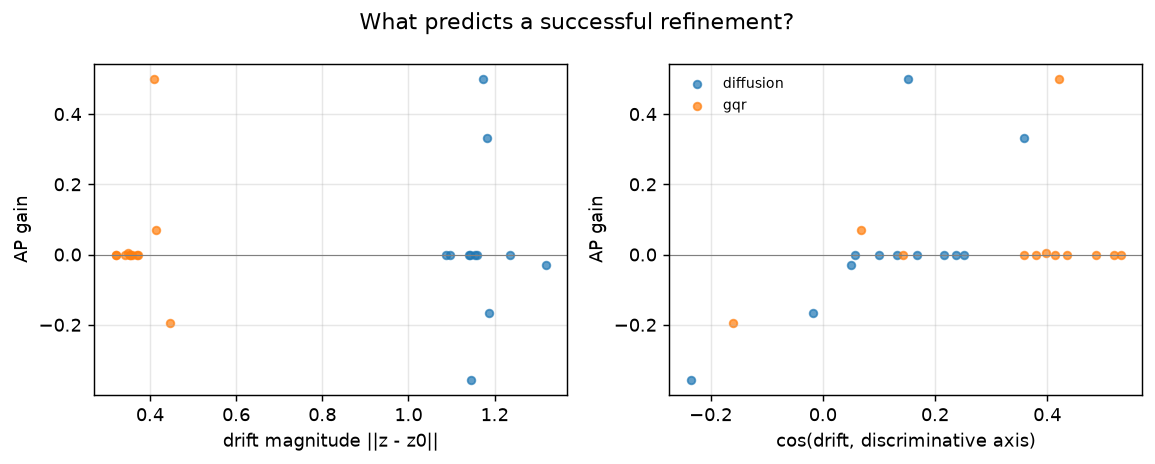
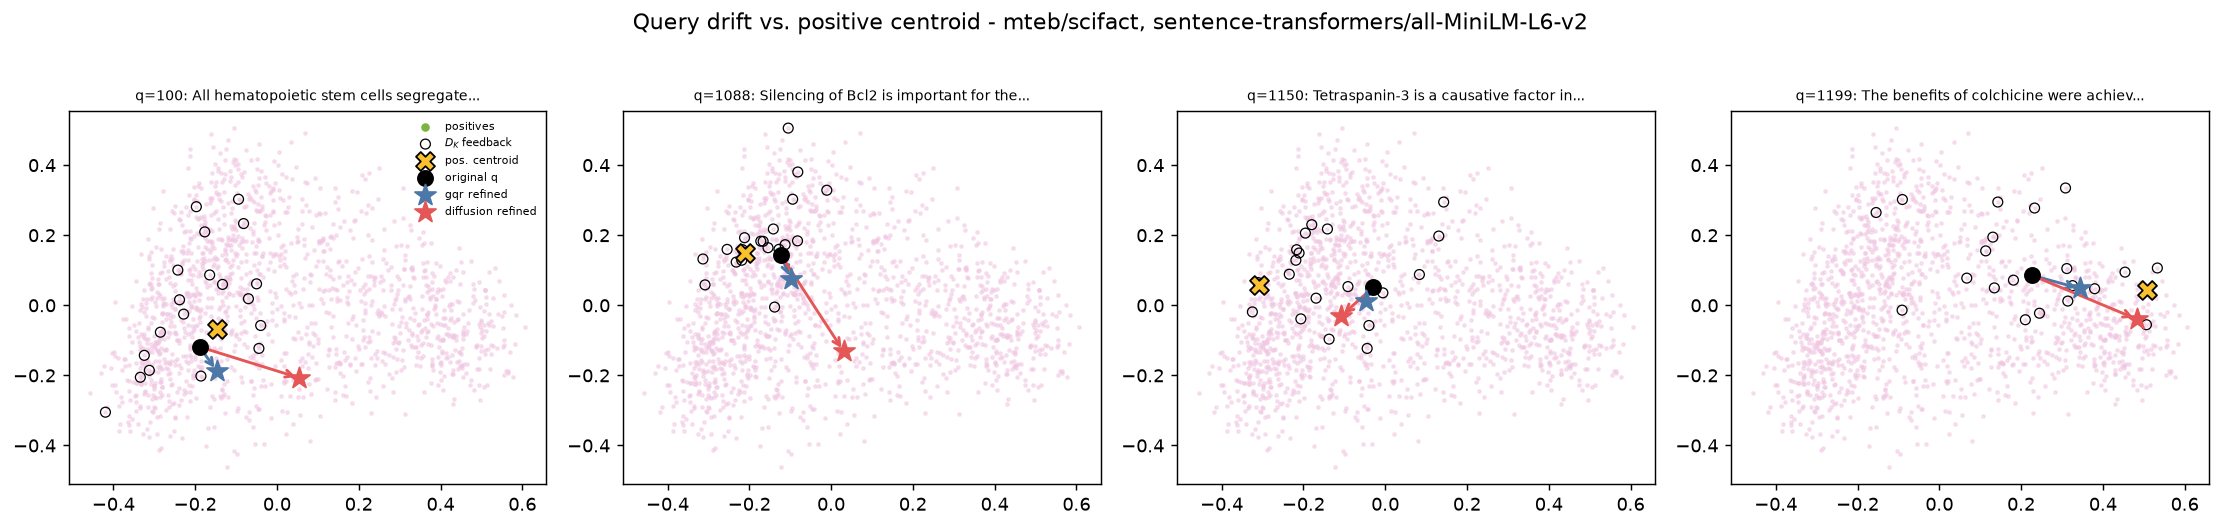

In [ ]:
!python analyze_refinement.py --recompute --n-queries 12


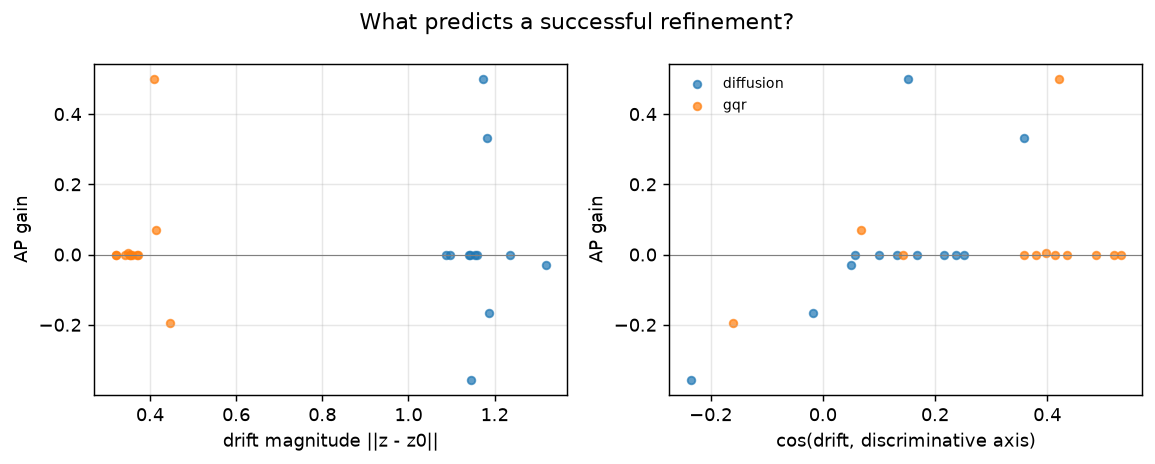
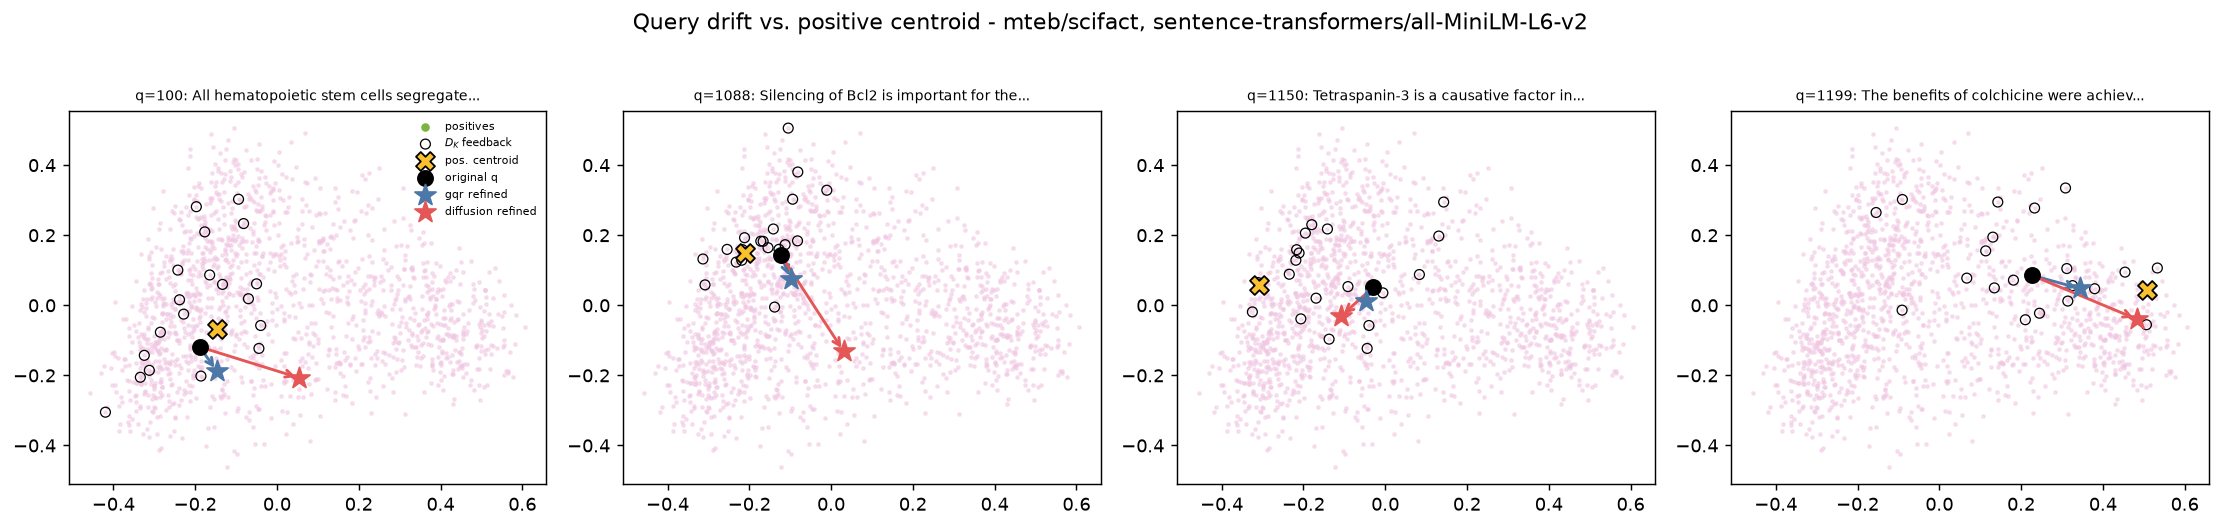

In [ ]:
from IPython.display import HTML
HTML(filename="analysis/report.html")